# 0. Page de garde

**Nom Prénom** : ALBURQUERQUE Julien  
**Formation** : CISIA — Concevoir et implémenter une solution d'intelligence artificielle (référentiel C1→C9)  
**Cas d'usage** : Détection précoce du décrochage étudiant en L1  
**Dépôt GitHub** : [cisia-decrochage-etudiant](https://github.com/jalb-code/cisia-decrochage-etudiant.git)  
**Date de soutenance** : 2026-09-01 — **Version du notebook** : v0.3 (2026-08-16) 

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from decrochage_l1 import eda
from decrochage_l1.config import settings
from decrochage_l1.data import preparation
from decrochage_l1.data.utils import cleaning_utils, profiling_utils

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 38)

## _Scaffolding du projet_

- **Création de la structure du projet** : Le code réutilisable dans `src/`, notebook unique `JALB-Decrochage-l1.ipynb` , données dans `data` non commité (voir journal de bord)
- **Hygiène de code** : format/lint (`ruff`), tests (`pytest`), `pre-commit` et intégration continue (GitHub Actions) → un livrable reproductible et vérifiable.

### _Journal de bord des décisions_

1. **[D01] Ne pas versionner les données.**  
⇒ Les fichiers data contiennent des données personnelles sensibles. Rien n'atteste formellement de leur caractère synthétique donc par précaution RGPD (minimisation), je les exclus du dépôt Git. Le dépôt cloné n'est donc pas exécutable en l'état - compromis assumé, la procédure de mise en place des données étant décrite dans le `README.md`.

 
2. **[D02] Utilisation de l'IA générative**  
⇒ J'ai choisi d'utiliser Claude Code pour m'assister dans la réalisation de ce projet. Au vu du temps limité que je peux y allouer et de la méta actuelle du développement logiciel, ce serait selon moi une erreur de ne pas l'utiliser. Il n'en reste pas moins qu'il s'agit d'un projet de certification où je dois démontrer mes compétences. C'est pourquoi j'ai décidé d'encadrer l'usage de l'IA de la manière suivante :
   - l'outil code selon mes directives et sous ma relecture ;
   - c'est moi qui prends les décisions, en m'appuyant sur des agents consultants pour m'éclairer avant de trancher (consultant ML, consultant RGPD, gardien du cas d'usage) ;
   - dans le notebook, les cellules de code sont écrites par l'IA sous mes directives ; les cellules markdown sont d'abord rédigées par moi, puis relues et corrigées par l'IA, avant une dernière relecture de validation de ma part.

# 1. Résumé exécutif

**Problème** : Dans une université pluridisciplinaire, ~28 % des étudiants de L1 de la cohorte abandonnent (1 479 sur 5 200). Aujourd'hui, l'abandon ne se constate qu'en fin de semestre — trop tard pour agir.

**Objectifs** : Concevoir une solution d'IA capable de prédire, **à mi-S1**, le risque de décrochage, afin de proposer un accompagnement au bon moment. 2 cibles de prédictions sont demandées: 
  - **Risque d'abandon** — score de risque (classification) : faut-il proposer un accompagnement ?
  - **Moyenne finale (/20)** — régression : calibrer et prioriser l'intensité de l'accompagnement.

## Approche

Une démarche de bout en bout, du besoin métier au service qui dure ; chaque étape est développée et **justifiée dans sa section** (journal de bord).

```mermaid
flowchart TD
    A["1 · Comprendre le besoin<br/>décrochage constaté trop tard → agir à mi-S1<br/>Section §2"]
    B["2 · Cadrer avant tout<br/>cibles · RGPD, éthique, responsabilités · aide à la décision<br/>Section §2–§4"]
    C["3 · Fiabiliser la donnée<br/>profilage · conformation · EDA<br/>exclusions de principe : anti-fuite, minimisation · features<br/>Section §5–§7"]
    D["4 · Modéliser et comparer<br/>baseline + ≥2 familles → départage sur AUC<br/>classification + régression<br/>Section §8–§9"]
    E["5 · Prouver et arbitrer<br/>métriques · seuil = coût FN&gt;FP · SHAP · audit d'équité<br/>Section §9, §12"]
    F["6 · Industrialiser<br/>pipeline sérialisé (score) · architecture cible<br/>Section §10–§11"]
    G["7 · Assumer les limites et durer<br/>limites connues · suivi de dérive · ré-entraînement · versioning<br/>Section §13–§14"]
    A --> B --> C --> D --> E --> F --> G
    G -.->|nouvelle promotion / dérive| C
```

## Résultats clés

- **Détection du décrochage (`abandon`)** : les modèles sont départagés sur l'**AUC = ⟨valeur — §12⟩** (indépendante du seuil) ; au seuil retenu, le modèle retrouve **⟨rappel en % — §12⟩** des décrocheurs.
- **Priorisation (`moyenne_finale`)** : régression de la note finale (**⟨RMSE/MAE — §12⟩**, R² = ⟨valeur — §12⟩), pour calibrer l'intensité de l'accompagnement.
- **Décision métier** : seuil fixé par l'**asymétrie des coûts** (un décrochage manqué coûte plus qu'un signalement à tort) : **⟨N — §12⟩** étudiants signalés, dont **⟨M — §12⟩** décrocheurs réels (précision ⟨% — §12⟩).
- **Explicabilité** : restitution **globale et locale** (SHAP)
- **Industrialisation** :  pipeline sérialisé + contrat `predict()`, architecture cible et suivi de dérive.

## Limites

- **Généralisation et dérive** : une seule cohorte (2024-2025, données synthétiques) et une validation intra-cohorte ⇒ le modèle est susceptible de devoir être **ré-entraîné** à la prochaine promotion.
- **Complétude des données** : manquants sur 10 colonnes ⇒ Mise en place de stratégie d'imputation comme parade à cette limite
- **Calibrage du seuil** : coûts métier (FN/FP) et capacité d'accompagnement non fournis ⇒ hypothèse de travail : un décrochage manqué (FN) pèse plus qu'un signalement à tort (FP), sans que ce dernier soit anodin.
- **Déployabilité conditionnée** : la mise en production dépend d'actes du responsable de traitement (AIPD, base légale confirmée par le DPO, information des étudiants) et d'effets de bord du marquage à documenter

*TODO — à compléter après §12 : cohorte unique et synthétique ; seuil à recalibrer par promotion.*

# 2. Cadrage métier et cas d'usage — journal de bord [C1]

## Problématique métier

Une université pluridisciplinaire constate un **taux d'abandon élevé en L1**. Aujourd'hui,
l'abandon se **constate en fin de semestre** - trop tard pour agir.

La **direction de la réussite étudiante** veut identifier, **dès mi-parcours du S1**, les
étudiants à risque de décrochage, pour déclencher un accompagnement - tutorat, soutien
méthodologique, aide sociale.

## Enjeux métier

- **Humain** - un décrochage laisse une trace **psychologique** (sentiment d'échec, perte de
  confiance, déclassement ressenti) et **professionnelle** (employabilité réduite, entrée
  retardée dans la vie active). Il est souvent **réversible s'il est repéré tôt**.
- **Institutionnel** - les ressources d'accompagnement sont **limitées** (heures de tutorat,
  aides) ⇒ il faut **cibler**. D'où le rôle de la cible secondaire `moyenne_finale` - prioriser
  et calibrer l'intensité - et de l'explicabilité - désigner les **facteurs** sur lesquels agir.
- **Économique** - un abandon est un investissement gaspillé et se répercute en cascade :
  - **l'étudiant** perd l'année engagée et s'expose au chômage ou à un emploi moins rémunérateur ;
  - **l'institution** perd les moyens publics investis pour le former ;
  - **la société** compte un diplômé de moins - productivité et recettes fiscales moindres.

## Objectifs et contraintes

Deux prédictions complémentaires à mi-S1 :

| Cible | Variable | Tâche | Rôle |
|---|---|---|---|
| **Principale** | `abandon` (0/1) | Classification binaire | Faut-il proposer un accompagnement ? |
| **Secondaire** | `moyenne_finale` (/20) | Régression | Prioriser et calibrer l'intensité |

La cible principale déclenche l'action ; la secondaire la **module**.

Trois contraintes pèsent dès le cadrage et orientent toute la chaîne :

- **Horizon mi-S1 - risque de fuite temporelle.** Une variable n'est légitime que si elle est
  **connue à mi-parcours** ; une donnée consolidée en fin de S1 (`moyenne_partiels_s1`,
  `nb_ue_validees_s1`) gonflerait la validation tout en rendant le modèle inexploitable en
  production. Reste à établir en **§3** quelles variables sont disponibles à mi-S1.
- **Explicabilité exigée - restitution SHAP.** L'énoncé impose des indicateurs **explicables** ;
  la solution prévoit une restitution **globale et locale** (SHAP) - voir journal de bord.
- **Éthique et RGPD - variables sensibles.** L'énoncé exige un usage **éthique et conforme** des
  données étudiantes ; biais portés par `sexe`, `boursier`, `etablissement_origine`. Cet aspect sera traité en **§4**.

## Rythme d'usage : une campagne par an

Le scoring s'exécute **une fois par an**, à mi-S1, sur **toute la promotion** en cours - il n'y a **pas de besoin temps réel**. Ce que ce rythme implique pour le contrat de service et le choix du modèle est tranché au journal de bord.

## Le coût d'une erreur : FN (décrochage manqué) >> FP (signalement à tort)

Le modèle peut se tromper de **deux façons**, qui n'ont ni les mêmes conséquences ni le même coût :

- **Faux négatif (FN) - un décrochage manqué.** Le modèle prédit « pas d'abandon » pour un
  étudiant qui décroche : aucun accompagnement n'est proposé à qui en aurait eu besoin, l'occasion
  d'agir à temps est perdue. **Coût le plus lourd, et souvent irréversible** - une chance de
  réussite qui ne revient pas pour l'étudiant, une année d'investissement perdue pour l'institution.
- **Faux positif (FP) - un signalement à tort.** Le modèle prédit « à risque » pour un étudiant
  qui ne décroche pas : une ressource limitée est mobilisée pour rien. **Coût borné et
  réversible** - un créneau de tutorat consommé en trop ; s'y ajoute, pour l'étudiant, une
  étiquette « à risque » qui n'est pas neutre.

**FN >> FP** : un étudiant perdu pèse plus qu'un créneau de tutorat dépensé. La solution doit donc privilégier le rappel (*recall*) sur `abandon` - mieux vaut un signalement à tort qu'un décrochage manqué. Sans pour autant tout signaler : les FP consomment la capacité d'accompagnement, limitée. Où placer le curseur, c'est le seuil - arbitré en §12.

## Parties prenantes

| Acteur | Rôle | Ce qu'on doit lui fournir |
|---|---|---|
| **Direction réussite étudiante** | Commanditaire | Une solution répondant aux objectifs qu'elle a définis. |
| **Tuteurs / responsables pédagogiques** | Utilisateurs | Un outil qui, à mi-S1, signale le risque, estime la moyenne finale et **explique** la prédiction, pour adapter l'accompagnement. |
| **Étudiant** | Sujet des données **et** bénéficiaire | Minimisation des données ; vigilance sur biais et stigmatisation |
| **DPO / référent éthique** | Garant de la conformité | Les livrables de conformité |
| **SI scolarité / LMS** | Fournisseur des données | Une proposition d'intégration technique |

## _Journal de bord des décisions_

1. **[D03·D04] FN ≫ FP, sans coût métier facilement chiffrable**  
⇒ Je départage les modèles sur la **ROC/AUC** - indépendante du seuil et fiable à déséquilibre modéré (~28/72) - **complétée par la PR-AUC**, qui rend compte de la performance sur la classe minoritaire (les décrocheurs) que la ROC/AUC lisse.  
⇒ Je reporte le réglage du seuil en §12 : sans montant ni capacité d'accompagnement, seul le sens de l'asymétrie est sûr, et aucun seuil ne se déduit par le calcul.

2. **[D05] Explicabilité imposée par l'énoncé**  
⇒ Je fournis une explicabilité globale et locale (SHAP) et j'en fais un critère de choix du modèle : le besoin des équipes pédagogiques est double - **global** (quels facteurs pèsent sur le risque) et **local** (pourquoi *cet* étudiant est signalé, pour adapter l'accompagnement).

3. **[D06] Usage : une campagne par an, sur toute la promotion**  
⇒ Je prévois d'intégrer dans la solution finale un point d'entrée qui score une promotion entière en une passe (endpoint /predict-cohorte);

# 3. Données : disponibilité, gouvernance et alternatives — journal de bord [C1]

## 3.1 Description des sources

Deux fichiers CSV sont fournis :

- **`decrochage_etudiants_complet_V5.csv`** - le jeu principal : ~5 200 lignes, 33 colonnes, une ligne par étudiant de L1, **une seule cohorte 2024-2025**, observée à mi-parcours du S1. Un échantillon de 50 lignes accompagne le fichier pour une première lecture.
- **`catalogue_formations_V5.csv`** - table de référence des filières, jointe au jeu principal par `filiere`.

L'ensemble des colonnes peut être classées par thème métier :

| Thème | Colonnes |
|---|---|
| Identifiants | `student_id`, `id_dossier` |
| Contexte d'inscription | `annee_universitaire`, `filiere`, `date_inscription` |
| Profil social et démographique | `age`, `sexe`, `boursier`, `distance_domicile_km`, `heures_travail_remunere_sem` |
| Parcours antérieur | `bac_type`, `mention_bac`, `etablissement_origine` |
| Engagement LMS | `connexions_lms_30j`, `heures_lms_total`, `ressources_consultees`, `messages_forum` |
| Assiduité et travail rendu | `taux_presence_pct`, `retards_rendus`, `nb_devoirs_total`, `nb_devoirs_rendus` |
| Résultats académiques | `moyenne_partiels_s1`, `nb_ue_total`, `nb_ue_validees_s1` |
| Ressenti déclaré | `motivation`, `satisfaction`, `sentiment_appartenance` |
| Avis du tuteur | `commentaire_tuteur` |
| Leurres annoncés | `groupe_td`, `couleur_carte_etudiante`, `jour_inscription` |
| Cibles | `abandon`, `moyenne_finale` |
| Information filière | Dans le 2nd fichier : `faculte`, `niveau`, `ects_semestre`, `capacite_accueil`, `volume_horaire_s1`, `taux_reussite_historique_pct` |

 ## 3.2 Disponibilité, accès et gouvernance

**Disponibilité et accès**

L'énoncé ne documente pas comment ces données sont collectées. Au vu de la nature des colonnes (traces LMS, dossier de scolarité, état civil, enquêtes déclaratives), je pose l'hypothèse d'un jeu assemblé automatiquement par l'université depuis ses outils (LMS, inscription…).

**Gouvernance, à notre niveau**

Les données ne servent qu'à l'entraînement et à l'évaluation des modèles. Elles ne sont pas conservées au-delà de la période de VSR (vérification de service régulier) qui suit la mise en production - ni archivage, ni réutilisation à d'autres fins. Corollaire : tout ré-entraînement (§13) suppose que l'université remette à disposition un jeu de données à jour - nous n'en gardons aucune copie dormante. La conformité RGPD d'ensemble (base légale, finalité, information des personnes) est traitée en §4 ; le stockage des paliers en §7.

## 3.3 Données connues à mi-S1 et fuite temporelle

Une variable n'est exploitable que si sa valeur **existe à mi-parcours** : en utiliser une qui n'est
connue que plus tard ferait reposer le modèle sur une information absente au moment du scoring - la
validation paraîtrait flatteuse, mais le modèle serait inexploitable en production.

**Cas des colonnes `moyenne_partiels_s1` et `nb_ue_validees_s1`**

Résultats consolidés en fin de S1 : les intégrer comme features à mi-S1 serait une fuite
temporelle. Je les place hors du périmètre de scoring.

**Cas de la colonne `commentaire_tuteur`**

Les libellés relevés sont des bilans de semestre (« bon semestre », « résultats fragiles aux
partiels ») - or les partiels tombent en fin de semestre. Je présume donc un champ **rédigé en fin
de S1**, hors horizon, que je place hors périmètre au même titre que les deux colonnes ci-dessus.
La présomption s'appuie aussi sur un fort volume d'absence.

**Cas des cibles `abandon` et `moyenne_finale`**

Ce sont les cibles de prédiction, constatées en fin de S1 : inconnues à mi-S1 par nature.

**Cas des autres colonnes**

Aucune information ne laisse penser qu'elles ne soient pas connues à mi-S1 : je les présume disponibles à mi-parcours - présomption, non preuve (D18).

## 3.4 Stratégie d'imputation des valeurs manquantes

Le constat chiffré - colonnes concernées et taux par colonne - est établi en §5 et analysé en §6 ;
ce que je fixe dès le cadrage, c'est la **stratégie**. Face à chaque colonne à manquants, je cherche
à situer son absence sur l'échelle **MCAR / MAR / MNAR** - c'est le mécanisme qui commande le
traitement. Ce mécanisme ne s'observe pas directement : je peux **rejeter MCAR**, mais distinguer
MAR de MNAR reste une hypothèse métier que je documente, sans prétendre la tester.

**Étape 1 - Je diagnostique, colonne par colonne**

- mesurer le taux de manquants ;
- tester le caractère manquant contre les **autres variables observées** - s'il en dépend, ce n'est
  pas du MCAR ;
- en déduire une présomption raisonnée de mécanisme.

**Étape 2 - Je décide par mécanisme**

| Mécanisme présumé | Traitement possible |
|---|---|
| **MCAR** - absence indépendante de tout | médiane / mode sur la totalité du train |
| **MAR** - absence expliquée par d'autres variables observées | médiane / mode par groupe + indicateur `x_manquant` si informatif |
| **MNAR** - absence liée à la valeur elle-même | remplacer l'absence par une modalité « Inconnu » déclarée (cat.) ou médiane + `x_manquant` (num.) |

**Important** : l'imputation sera réalisée sur le train uniquement. C'est la garantie **anti-fuite**.

## 3.5 Enrichissement : catalogue, cohorte, ré-échantillonnage

**Catalogue des filières**

Toutes ses colonnes - faculté, niveau, ECTS, capacité, volume horaire, taux de réussite historique - sont des attributs de la filière : à filière donnée, leur valeur est fixe. Ce sont donc des fonctions déterministes de filiere, déjà présente dans le jeu étudiant - les joindre n'introduit aucune information nouvelle, seulement une réécriture de filiere.

**Une seule cohorte** 

Le jeu ne couvre que 2024-2025. Le modèle risque d'être spécifique à cette
promotion et de dériver aux suivantes - d'où la nécessité d'un ré-entraînement sur plusieurs
années et d'un suivi de dérive (§13). Limite à documenter et surveiller, pas à corriger ici.

**Déséquilibre de classes** 

Le taux d'abandon annoncé (~28 %) est un déséquilibre modéré : il ne justifie pas un ré-échantillonnage (SMOTE), qui fabriquerait des exemples synthétiques pour un gain douteux. Une pondération des classes (class_weight) suffit si besoin. Le taux exact sera confirmé en §6 - seule mesure susceptible de rouvrir la question.

## 3.6 Les leurres annoncés

L'énoncé désigne trois leurres : `groupe_td`, `couleur_carte_etudiante`, `jour_inscription`. Aucun
n'a de lien causal plausible avec le décrochage, et `jour_inscription` paraît n'être que le jour de
semaine de `date_inscription`. Je ne les exclus pas pour autant : je les **conserve dans le gold** et
je démontre leur nullité, plutôt que de la supposer, par trois contrôles convergents.

- **Redondance** - `jour_inscription` reproduit-il le jour de semaine de `date_inscription` ? (§6)
- **Lien bivarié** - chaque leurre est-il associé à `abandon`, seul à seul ? (§6)
- **Poids multivarié** - une fois dans le modèle, pèsent-ils ? SHAP ≈ 0 attendu (§12)

## _Journal de bord des décisions_

1. **[D07] `commentaire_tuteur` hors périmètre de scoring**  
⇒ Présumé rédigé en fin de S1 (contenu de bilan + ~49 % de vides) : l'employer à mi-S1 serait une fuite temporelle.

1. **[D08] Pas d'enrichissement avec le catalogue de formation**  
⇒ Toutes ses colonnes sont des fonctions déterministes de filiere, déjà présente : les joindre n'ajoute aucune information, seulement une réécriture.

1. **[D09] Valeurs manquantes : imputer selon le mécanisme**  
⇒ Le mécanisme d'absence (MCAR/MAR/MNAR) commande le traitement ; le diagnostic est mené en §6 et l'imputation ajustée dans le train seul. *Écarté* : la suppression des lignes incomplètes - elle biaise dès que l'absence n'est pas MCAR et sacrifie des décrocheurs (classe rare).

1. **[D10] Pas de ré-échantillonnage (SMOTE)**  
⇒ Le déséquilibre annoncé (~28 %) est modéré et ne le justifie pas ; une pondération des classes suffit si nécessaire. Le taux sera confirmé en §6 - seule mesure susceptible de rouvrir la question.

1. **[D11] Leurres : conservés et démontrés nuls, plutôt qu'exclus a priori**  
⇒ Je les garde dans le gold et démontre leur nullité par trois contrôles convergents - redondance et lien bivarié (EDA, §6), poids multivarié (SHAP, §12) - au lieu de les croire nuls. Écarté - les exclure a priori sur « aucun sens métier », jugement contestable qui prive de la preuve sans rien économiser.

1. **[D18] Les colonnes hors résultats fin-de-S1 sont présumées connues à mi-S1**  
⇒ Faute de documentation sur l'horizon de collecte, je présume disponibles à mi-parcours toutes les colonnes hors résultats consolidés (D07) et cibles - c'est une **présomption raisonnée, pas une preuve**. En production, le contrat d'entrée fige cet horizon. *Écarté* - inclure une variable au statut temporel douteux : gain de validation qui ne se retrouverait pas en production (fuite).


# 4. Enjeux éthiques, sociétaux et conformité — journal de bord [C2]

## 4.1 Base légale et finalité

Le traitement doit reposer sur une base légale avant toute autre considération. Je retiens la **mission d'intérêt public** (art. 6.1.e) : l'aide à la réussite étudiante relève des missions de service public de l'établissement. Cette base **dispense du consentement** - l'accompagnement ne saurait être conditionné à un accord préalable, ni laisser un étudiant renoncer à une aide. Elle suppose un rattachement à une base en droit national (art. 6.3) et doit être **confirmée par le DPO**. Elle a un mérite second : elle évite le point dur du consentement pour les étudiants mineurs, qu'une cohorte de L1 peut compter.

La **finalité est déterminée** (art. 5.1.b) : proposer un **accompagnement pédagogique**. Tout autre usage est proscrit et consigné dans la fiche du modèle - sélection à l'entrée, réorientation subie, évaluation des enseignants. La cible secondaire `moyenne_finale` relève du même cadre : une aide à la décision d'accompagnement, **jamais** une note anticipée ni un instrument d'évaluation.

## 4.2 Minimisation et données identifiantes

Le principe de **minimisation** (art. 5.1.c) commande de ne traiter que les données **nécessaires à la finalité** : le seul pouvoir prédictif d'une variable ne suffit pas à la justifier. Il gouverne les exclusions de ce chapitre (§4.4) et le sort des variables démontrées inutiles (D16).

Les identifiants `student_id` et `id_dossier` **n'entrent pas dans le modèle** : ils identifient un dossier, ils ne portent aucune information généralisable. Le contrat d'API pourra accepter un identifiant, mais **au seul titre de la corrélation** entre une requête et sa réponse, à l'usage de l'appelant ; la solution ne le **journalise ni ne le conserve**. Les modalités de conservation côté établissement relèvent de sa responsabilité (§4.7).

## 4.3 Décision automatisée et droit à l'explication

Le système ne prend **aucune décision** au sens de l'art. 22 : il produit une **probabilité de décrochage**, et l'équipe pédagogique décide de l'accompagnement (garde-fous en §4.6). L'humain n'est pas une validation de façade - c'est lui qui arbitre, la probabilité n'étant qu'un signal parmi d'autres.

Le **droit à l'explication** est servi par l'explicabilité du modèle : pour chaque étudiant signalé, la **contribution de ses variables** (SHAP, local et global) est restituée. Ce droit se rattache aux **art. 13-14** (information sur la logique sous-jacente), non à l'art. 15 qui vise l'accès de la personne à ses propres données. L'explicabilité est déjà actée comme critère de choix du modèle (D05, §2) et démontrée en §12.

## 4.4 Variables protégées et proxies socio-économiques

Le jeu porte deux **caractéristiques protégées au sens du droit de la non-discrimination** - le `sexe` et le statut `boursier` - non des données sensibles de l'art. 9 RGPD, qui ne couvre ni l'un ni l'autre. L'**art. 225-1 du Code pénal** interdit de distinguer les personnes sur le fondement du sexe et de la « particulière vulnérabilité résultant de la situation économique », à laquelle le statut boursier se rattache.

Je les **exclus du modèle par principe** - de non-discrimination et de minimisation - **quel que soit leur pouvoir prédictif** (D13). Elles ne disparaissent pas du jeu pour autant : conservées **hors modèle**, elles servent l'**audit d'équité** par sous-groupes (§12), qui vérifie que le modèle ne rate pas davantage de décrocheurs selon le sexe ou le statut boursier.

Trois variables ne sont pas protégées mais appellent un contrôle : `etablissement_origine`, `heures_travail_remunere_sem`, `distance_domicile_km`. On peut soupçonner qu'elles laissent **déduire la situation économique** de l'étudiant - la même information que porte `boursier`, exclu ci-dessus. Les intégrer sans vérification risquerait de **ré-encoder** cette variable protégée écartée (discrimination indirecte). Je conditionne donc leur entrée dans le modèle à l'**absence de corrélation avec `boursier`** - contrôle reporté à l'EDA (§6, D14).

## 4.5 Biais de représentation

Un modèle apprend mal ce que les données représentent peu. Outre le biais de *décision* (§4.6), il faut surveiller le biais de *représentation* : une modalité rare - le `sexe` renseigné « Autre », un type d'établissement marginal - risque d'être mal apprise, et le modèle peu fiable sur le groupe correspondant. Le repérage de ces modalités est reporté à l'EDA (§6) ; selon le résultat, une modalité insuffisamment représentée est soit **regroupée** (modalité « Autre » déclarée), soit **signalée comme zone de moindre fiabilité** ; dans les deux cas, l'**audit d'équité** couvre ces modalités rares (§12, D17), pour vérifier que la performance ne s'effondre pas sur ces groupes peu représentés.

## 4.6 Marquage, stigmatisation et garde-fous

Signaler un étudiant n'est pas neutre. **Ne pas signaler** le laisse sans proposition d'aide - le risque même que le projet entend réduire. **Signaler** ouvre deux risques opposés : la **prophétie auto-réalisatrice** - un étudiant désigné « à risque » peut intérioriser ce jugement - et la **stigmatisation** si l'information circule au-delà de ceux qui accompagnent. Aucun n'est nul ; les garde-fous visent à les contenir.

**Côté établissement**

- la probabilité n'est **jamais** le seul critère de déclenchement ; la décision revient à l'**équipe pluridisciplinaire** ;
- l'étudiant peut **refuser** un accompagnement, et peut en **demander** un même à probabilité faible - c'est l'équipe qui statue ;
- il incombe à l'établissement de **s'assurer que ces garde-fous sont effectifs**, et pas seulement affichés.

**Côté solution**

- exposer une **probabilité**, non une étiquette `abandon` Oui/Non ; l'étiquette sert au réglage du seuil (§12) mais reste **masquée en production**, pour ne pas « marquer » l'étudiant (D15).

## 4.7 Ce qui relève du responsable de traitement

L'établissement est **responsable de traitement** ; la solution agit comme **sous-traitant** (art. 28). Les points suivants sont cadrés ici mais **produits par l'établissement**, hors périmètre du notebook :

- **information des personnes** (art. 13-14) - informer les étudiants de l'existence du traitement et de sa logique ;
- **conservation** (art. 5.1.e) - durée limitée à ce que la finalité exige ; cohérent avec §3.2, aucune copie dormante côté solution ;
- **sécurité** (art. 32) - mesures techniques et organisationnelles de protection des données ;
- **analyse d'impact** (AIPD, art. 35) - le profilage d'un public étudiant en fait un traitement candidat.

## _Journal de bord des décisions_

1. **[D12] Base légale = mission d'intérêt public (art. 6.1.e)**  
⇒ Je fonde le traitement sur la mission de service public d'aide à la réussite, ce qui dispense du consentement ; à confirmer par le DPO et à rattacher à une base en droit national. *Écarté* - le consentement (art. 6.1.a) : il conditionnerait l'accompagnement à un accord préalable et laisserait un étudiant renoncer à une aide, à rebours de la finalité.

2. **[D13] Variables protégées exclues du modèle par principe**  
⇒ `sexe` et `boursier` (motifs de l'art. 225-1) sont retirés du vecteur de features quel que soit leur pouvoir prédictif ; conservés hors modèle pour l'audit d'équité (§12). *Écarté* - les conserver pour leur pouvoir prédictif : gain possible mais discrimination directe et effet stigmatisant, que la minimisation proscrit dès lors que la finalité n'en dépend pas.

3. **[D14] Proxies socio-économiques : intégration conditionnée à l'absence de corrélation avec `boursier`**  
⇒ `etablissement_origine`, `heures_travail_remunere_sem`, `distance_domicile_km` peuvent laisser déduire la situation économique, comme `boursier` (exclu) ; leur entrée dans le modèle est conditionnée à un contrôle de non-corrélation avec `boursier` (§6), pour ne pas ré-encoder la variable protégée écartée. *Écarté* - les inclure sur leur seul pouvoir prédictif, sans contrôle : conserverait un proxy potentiellement corrélé au protégé.

4. **[D15] Exposer une probabilité, masquer l'étiquette en production**  
⇒ La solution restitue une probabilité, non une étiquette `abandon` Oui/Non ; l'étiquette sert au réglage du seuil (§12) mais reste masquée en production, pour ne pas « marquer » l'étudiant ; la décision reste à l'équipe pluridisciplinaire (art. 22). *Écarté* - exposer l'étiquette : plus lisible, mais crée une catégorie « à risque » stigmatisante et une décision de fait automatisée.

5. **[D16] Retrait des variables à poids nul de l'artefact déployé (minimisation)**  
⇒ Toute variable dont l'ajustement (§9) établit un poids SHAP ≈ 0 - leurre (D11) ou proxy non prédictif - est retirée du pipeline déployé (§10) par minimisation (art. 5.1.c) : démontrer nul, puis retirer, jamais retirer avant. Généralise D11. *Écarté* - la conserver dans l'artefact (inoffensive à poids nul) : contraire à la minimisation, qui proscrit d'embarquer une donnée que la finalité n'utilise pas.

6. **[D17] Audit d'équité étendu aux modalités rares**  
⇒ Au-delà des attributs protégés (D13), l'audit d'équité (§12) couvre les modalités rares repérées en §6 : je vérifie que la performance ne s'effondre pas sur ces groupes peu représentés.

# 5. Chargement et compréhension des données [C3]

**Objectif** : établir ce que les fichiers contiennent, comment c'est écrit et ce qui cloche - doublons exacts, nombres restés en texte, dates multi-formats, casse et accents hétérogènes - puis normaliser ces écritures pour produire un DataFrame exploitable, support de l'EDA. Constat et mise en forme seuls : aucune ligne ni colonne n'est arbitrée ici.

## 5.1 Profilage des fichiers

> Automatisation du profilage des données via un script Python.

Ce profilage réalise un pré-nettoyage de base (suppression des espaces, de la casse et des accents) pour restituer d'un coup, dans un rapport HTML par fichier :

- des **métriques sur le fichier** : délimiteur, encodage, taille, nombre de lignes et de doublons ;
- des **métriques sur les colonnes** :
  - le type réel détecté par pandas (`type_reel`) ;
  - le type sémantique déduit du profilage - identifiant, constante, catégorielle, date, nombre… (`type_semantique`) ;
  - les motifs d'écriture des valeurs et leur distribution (`motif_dominant`, `n_motifs` - cliquable pour visualiser tous les motifs dans le rapport) ;
  - le nombre de valeurs distinctes, brutes et normalisées (`n_distinct`, `n_distinct_normalise`) ;
  - les bornes de la colonne (`min`, `max`) ;
  - le pourcentage de valeurs nulles (`null_%`) ;
  - la liste exhaustive des modalités pour les colonnes catégorielles (`exemples` - cliquable).

In [30]:
# `report_dir` déclenche l'écriture du rapport HTML complet - hors dépôt, car il cite
# des valeurs brutes. Sans lui, mesurer ne touche pas au disque.
profils = {
    chemin.name: profiling_utils.profile_csv(chemin, report_dir=settings.report_dir)
    for chemin in sorted(settings.raw_dir.glob("*.csv"))
}
profil_catalogue, profil_etudiants = sorted(profils.values(), key=lambda profil: profil.file.n_rows)

# Liens vers les rapports HTML complets
liens = "\n".join(
    f"- [{profil.report_path.name}]"
    f"(../{profil.report_path.relative_to(settings.root_dir).as_posix()})"
    for profil in profils.values()
    if profil.report_path is not None
)
display(Markdown(f"**> Rapports de profilage générés**\n\n{liens}"))

**> Rapports de profilage générés**

- [profil-dataset_catalogue_formations_V5.html](../reports/profil-dataset_catalogue_formations_V5.html)
- [profil-dataset_decrochage_etudiants_complet_V5.html](../reports/profil-dataset_decrochage_etudiants_complet_V5.html)

### Interprétation

La lecture des rapports de profilage permet de détecter les erreurs de format, les valeurs de même sens métier écrites différemment, et les valeurs aberrantes.

#### Fichier `catalogue_formations_V5`

🔍 **`filiere` : 8 valeurs pour 8 lignes**  
⇒ clé primaire de la table, à utiliser comme clé de jointure

🔍 **Les autres colonnes sont des attributs de la filière** (faculté, ECTS, capacité, volume horaire, taux de réussite historique)  
⇒ non jointes au jeu étudiant (cf. D08, §3.5)

#### Fichier `decrochage_etudiants_complet_V5`

🔍 **40 lignes strictement identiques** sur les 33 colonnes  
⇒ doublons à supprimer

🔍 **`annee_universitaire` constante** (`2024-2025`) - 1 seule modalité

🔍 **`commentaire_tuteur` : variable catégorielle à 19 modalités**, pas du texte libre

🔍 **Formats hétérogènes** ⇒ à corriger

  - chiffres restés en texte : `date_inscription` (3 formats : `%Y-%m-%d`, `%d/%m/%Y`, `%d %b %Y`) · `taux_presence_pct` (« % » + virgule) · `distance_domicile_km` (« km » + virgule) · `moyenne_partiels_s1` (virgule)
  - catégorielles (casse / accents / espaces) : `filiere` (31→8) · `bac_type` (12→7) · `sexe` (11→8) · `mention_bac` (11→8) · `boursier` (8→6) · 


🔍 **Valeurs hétérogènes à recoder** - même sens métier sous plusieurs écritures ; vocabulaire cible décidé arbitrairement ⇒ à recoder

  - `sexe` : 
    - `f`/`femme` → `femme` 
    - `h`/`m`/`homme` → `homme` 
    - `nb`/`autre` → `autre` 
    - `nr` → `non renseigné`
  - `bac_type` : 
    - `gen`/`general`/`generale` → `general` 
    - `techno`/`technologique` → `technologique` 
    - `pro`/`professionnel`→ `professionnel` 
  - `mention_bac` : 
    - `p`/`passable` → `passable` 
    - `ab`/`assez bien` → `assez bien` 
    - `b`/`bien` → `bien` 
    - `tb`/`tres bien`→ `tres bien` 
  - `boursier` : 
    - `non`/`n`/`0` → `non` 
    - `oui`/`o`/`1`→ `oui` 

🔍 **Aucune valeur aberrante à l'analyse des bornes**

- `age` entre 17 et 27 ans ⇒ cohérent avec l'âge d'un étudiant
- `heures_travail_remunere_sem` entre 0 et 28 h ⇒ cohérent avec une semaine de travail
- `taux_presence_pct` entre 34,8 et 99,9 % ⇒ cohérent avec un pourcentage
- `distance_domicile_km` entre 0 et 138 km ⇒ cohérent avec une distance en km
- `motivation`, `satisfaction`, `sentiment_appartenance` entre 1 et 5 ⇒ cohérent avec une échelle d'accord
- `moyenne_partiels_s1` entre 0 et 20 ⇒ cohérent avec une note sur 20
- `moyenne_finale` entre 0,22 et 19,9 ⇒ cohérent avec une note sur 20

### Nettoyage et recodage des écritures

J'applique les décisions de mise en forme en trois temps colonne par colonne 
- **(1)** le **nettoyage** convertit chaque colonne selon ce qu'elle représente - les nombres en nombres (virgule décimale, unité collée), les dates en dates (les trois formats relevés), tout le reste ramené à une forme de comparaison (minuscules, sans accent, espaces réduits)
- **(2)** le **recodage** des modalités de même sens métier vers un libellé de référence
- **(3)** le **dédoublonnage** des lignes en doubles

In [31]:
# Jeu de travail : `preparation.transform` conforme les écritures, recode le vocabulaire métier et
# retire les doublons exacts - sans rien écrire sur disque (le palier, c'est §7).
df_etudiants_clean, transfo = preparation.transform(profil_etudiants.data, profil_etudiants.columns)

In [32]:
# Contrôle : effet de la normalisation puis du recodage sur le nombre de modalités.
# `blank_to_na` exclut les cellules vides du décompte brut - comme le fait le rapport
# de profilage pour `n_distinct` : un blanc est une absence, pas une modalité.
SUIVIES = ("filiere", "bac_type", "mention_bac", "sexe", "boursier", "etablissement_origine")
apercu = pd.DataFrame(
    {
        "brut": {
            c: cleaning_utils.blank_to_na(profil_etudiants.data[c]).nunique() for c in SUIVIES
        },
        "normalisé": {
            c: cleaning_utils.normalize_text(profil_etudiants.data[c]).nunique() for c in SUIVIES
        },
        "recodé": {c: df_etudiants_clean[c].nunique() for c in SUIVIES},
    }
).rename_axis("colonne")
display(apercu)

brut = len(profil_etudiants.data)
display(
    Markdown(
        f"Lignes : **{brut}** → **{len(df_etudiants_clean)}** "
        f"(**{brut - len(df_etudiants_clean)}** doublons exacts retirés)"
    )
)

,brut,normalisé,recodé
colonne,,,
filiere,31,8,8
bac_type,12,7,3
mention_bac,11,8,4
sexe,11,8,4
boursier,8,6,2
etablissement_origine,4,4,4


Lignes : **5240** → **5200** (**40** doublons exacts retirés)

✅ Jeu de travail construit - écritures normalisées, modalités recodées, doublons exacts retirés

## 5.2 Contrôles qualités

Le profilage raisonne **colonne par colonne** : il ne voit pas les incohérences *entre* colonnes, *entre lignes*, ni *entre fichiers*. Je vérifie donc sur le jeu de travail trois relations que lui ne peut pas contrôler :
- l'unicité des identifiants (une ligne = un étudiant),
- la correspondance de `filiere` avec le catalogue (jointure possible),
- et trois inégalités métier ligne à ligne.

In [33]:
# Chaque contrôle rend un NOMBRE D'ANOMALIES - 0 signifie cohérent. Aucun n'est visible
# au profil, qui raisonne colonne par colonne : ni les doublons d'un identifiant, ni la
# jointure au catalogue, ni les inégalités entre deux colonnes d'une même ligne.
reference = set(cleaning_utils.normalize_text(profil_catalogue.data["filiere"]))
filieres = cleaning_utils.normalize_text(df_etudiants_clean["filiere"])

# Inégalités métier à respecter ligne à ligne (colonne inférieure, colonne supérieure).
# Une ligne dont une valeur manque n'est pas comparable : écartée, jamais tenue conforme.
CONTRAINTES = (
    ("nb_devoirs_rendus", "nb_devoirs_total"),
    ("nb_ue_validees_s1", "nb_ue_total"),
    ("retards_rendus", "nb_devoirs_rendus"),
)

anomalies = {
    "Doublons de student_id": int(df_etudiants_clean["student_id"].duplicated().sum()),
    "Doublons de id_dossier": int(df_etudiants_clean["id_dossier"].duplicated().sum()),
    "Filières hors catalogue": len(set(filieres.dropna()) - reference),
}
for petite, grande in CONTRAINTES:
    paire = df_etudiants_clean[[petite, grande]].dropna()
    anomalies[f"Lignes où {petite} > {grande}"] = int((paire[petite] > paire[grande]).sum())

controles = pd.Series(anomalies, name="anomalies").rename_axis("Contrôle").to_frame()
display(controles)

,anomalies
Contrôle,
Doublons de student_id,0
Doublons de id_dossier,0
Filières hors catalogue,0
Lignes où nb_devoirs_rendus > nb_devoirs_total,0
Lignes où nb_ue_validees_s1 > nb_ue_total,0
Lignes où retards_rendus > nb_devoirs_rendus,0


### Interprétation

🔍 0 anomalie sur les six contrôles

- `student_id` et `id_dossier` uniques (une ligne = un étudiant)
- toutes les filières présentes au catalogue (jointure possible)
- inégalités métier respectées (devoirs rendus ≤ dus, UE validées ≤ total, retards ≤ rendus)

✅ Jeu de travail cohérent - identifiants uniques, filières appariées, inégalités métier respectées

## 5.3 Bilan

**> Étudiants** (5 200 lignes, 33 colonnes)

| Colonne | Type après nettoyage | Traitement | % nuls | Bornes / modalités |
|---|---|---|---|---|
| `student_id` | identifiant (texte) | nettoyage | - | 5 200 modalités |
| `id_dossier` | identifiant (texte) | nettoyage | - | 5 200 modalités |
| `annee_universitaire` | constante (texte) | nettoyage | - | 1 modalité |
| `filiere` | catégoriel | nettoyage | - | 8 modalités |
| `sexe` | catégoriel | nettoyage + recodage | - | 4 modalités |
| `bac_type` | catégoriel | nettoyage + recodage | - | 3 modalités |
| `mention_bac` | catégoriel | nettoyage + recodage | 4 % | 4 modalités |
| `etablissement_origine` | catégoriel | nettoyage | 5 % | 4 modalités |
| `boursier` | binaire (oui/non) | nettoyage + recodage | - | 2 modalités |
| `groupe_td` | catégoriel | nettoyage | - | 8 modalités |
| `couleur_carte_etudiante` | catégoriel | nettoyage | - | 5 modalités |
| `jour_inscription` | catégoriel | nettoyage | - | 5 modalités |
| `commentaire_tuteur` | catégoriel | nettoyage | 49,29 % | 19 modalités |
| `date_inscription` | date | nettoyage (3 formats) | - | 2024-09-02 → 2024-09-27 |
| `age` | entier | aucun | - | 17 → 27 |
| `distance_domicile_km` | décimal | nettoyage (unité « km », virgule) | 6 % | 0 → 138 |
| `heures_travail_remunere_sem` | décimal | aucun | 12 % | 0 → 28 |
| `taux_presence_pct` | décimal | nettoyage (unité « % », virgule) | - | 34,8 → 99,9 |
| `connexions_lms_30j` | entier | aucun | 4 % | 0 → 81 |
| `heures_lms_total` | décimal | aucun | - | 0 → 170,5 |
| `ressources_consultees` | entier | aucun | - | 0 → 222 |
| `retards_rendus` | entier | aucun | - | 0 → 10 |
| `nb_devoirs_total` | entier | aucun | - | 8 → 13 |
| `nb_devoirs_rendus` | entier | aucun | - | 0 → 13 |
| `messages_forum` | entier | aucun | - | 0 → 18 |
| `moyenne_partiels_s1` | décimal | nettoyage (virgule) | 3 % | 0 → 20 |
| `nb_ue_total` | entier | aucun | - | 5 → 7 |
| `nb_ue_validees_s1` | entier | aucun | - | 0 → 7 |
| `motivation` | entier | aucun | 5 % | 1 → 5 |
| `satisfaction` | entier | aucun | 8 % | 1 → 5 |
| `sentiment_appartenance` | entier | aucun | 7 % | 1 → 5 |
| `moyenne_finale` | décimal | aucun | - | 0,22 → 19,9 |
| `abandon` | binaire (0/1) | aucun | - | 0 → 1 |


# 6. Analyse exploratoire (EDA) : visualisations et interprétation — journal de bord [C3]

**Objectif** : mesurer et interpréter le **jeu de travail conformé de §5** pour décider - cibles, manquants, variables à écarter - sans modifier aucune donnée ; les décisions s'appliquent au gold (§7) et au Pipeline (§9).

In [34]:
eda.set_style()

# §6 mesure sur le JEU DE TRAVAIL CONFORMÉ de §5 (nombres typés, dates parsées, vocabulaire
# recodé) - le bronze littéral est inexplorable. §7 rejouera ces mêmes règles depuis la source.
jeu: pd.DataFrame = df_etudiants_clean
cible_abandon, cible_moyenne = jeu["abandon"], jeu["moyenne_finale"]

# Périmètre de scoring : ce qui existe à mi-S1. La fuite temporelle est cadrée en §3 - ici on
# s'appuie dessus, on ne la re-tranche pas. Identifiants, constante et colonnes
# de fin de S1 sortent.
HORS_PERIMETRE = [
    "student_id",
    "id_dossier",
    "annee_universitaire",  # identifiants + constante (§5)
    "abandon",
    "moyenne_finale",  # cibles
    "moyenne_partiels_s1",
    "nb_ue_validees_s1",  # consolidées fin S1 (§3, D06)
    "commentaire_tuteur",  # bilan rédigé fin S1 (§3, D07)
]
# `str(c)` : les noms de colonnes sont typés Hashable par pandas ; les forcer en `str` donne à
# explicatives / num_cols / cat_cols un type `list[str]`, sans quoi `jeu[num_cols]` serait vu
# comme `Series | DataFrame` et refusé par les fonctions attendant un DataFrame.
explicatives: list[str] = [str(c) for c in jeu.columns if str(c) not in HORS_PERIMETRE]
num_cols: list[str] = [c for c in explicatives if pd.api.types.is_numeric_dtype(jeu[c])]
cat_cols: list[str] = [
    c
    for c in explicatives
    if not pd.api.types.is_numeric_dtype(jeu[c])
    and not pd.api.types.is_datetime64_any_dtype(jeu[c])
]

display(
    Markdown(
        f"Périmètre exploré : **{len(explicatives)}** explicatives "
        f"(**{len(num_cols)}** numériques, **{len(cat_cols)}** catégorielles) · "
        f"**{len(HORS_PERIMETRE)}** colonnes hors périmètre (cf §3)"
    )
)

Périmètre exploré : **25** explicatives (**15** numériques, **9** catégorielles) · **8** colonnes hors périmètre (cf §3)

## 6.1 Déséquilibre de la cible `abandon`

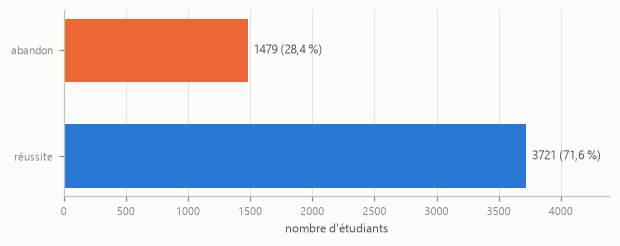

Prévalence de l'abandon **28.4 %** · rapport de déséquilibre **2.5:1**

In [35]:
# Barres horizontales : une couleur par classe, l'étiquette porte l'effectif ET la part.
balance = (
    eda.class_balance(cible_abandon)
    .assign(classe=lambda d: d["modalite"].map({"0": "réussite", "1": "abandon"}))
    .dropna(subset=["classe"])
    .sort_values("n", ascending=False)  # réussite en bas, abandon en haut
)
COULEURS = {"réussite": eda.PALETTE["series_1"], "abandon": eda.PALETTE["series_2"]}

figure, axis = plt.subplots(figsize=(6.4, 2.2))
axis.barh(
    balance["classe"], balance["n"], color=[COULEURS[c] for c in balance["classe"]], height=0.6
)
for y, (n, part) in enumerate(zip(balance["n"], balance["part_%"], strict=True)):
    axis.text(
        n,
        y,
        f"  {n} ({part:.1f} %)".replace(".", ","),
        va="center",
        ha="left",
        fontsize=8,
        color=eda.PALETTE["ink_secondary"],
    )
axis.set_xlabel("nombre d'étudiants")
axis.set_xlim(0, int(balance["n"].max() * 1.18))
axis.grid(axis="y", visible=False)
eda.show(figure)

display(
    Markdown(
        f"Prévalence de l'abandon **{100 * cible_abandon.mean():.1f} %** · "
        f"rapport de déséquilibre **{eda.imbalance_ratio(cible_abandon):.1f}:1**"
    )
)

### Interprétation

🔍 **Abandon = 28,4 % · rapport de déséquilibre 2,5:1**  
⇒ déséquilibre modéré, aucun rééchantillonnage - confirme D10  
⇒ pondération des classes (`class_weight`) à vérifier au choix du modèle §8/§9, pas une nécessité ici

## 6.2 Lien entre les deux cibles

Les deux cibles sont-elles indépendantes, ou `abandon` n'est-il que le seuillage de `moyenne_finale` ?

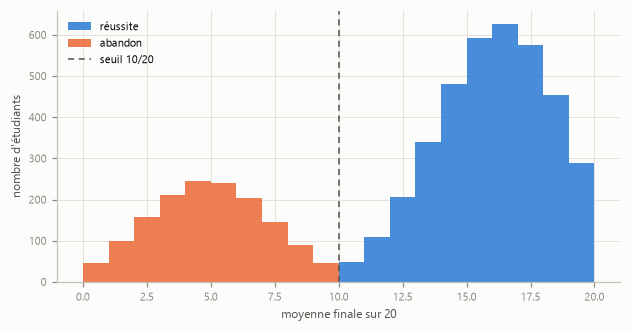

**Meilleur note d'un décrocheur** : 9.92<br>**Pire note d'un reçu** : 10.03<br>`abandon == (moyenne_finale < 10)` sur **100 %** des lignes

In [36]:
SEUIL_VALIDATION = 10  # une moyenne finale >= 10/20 vaut validation de l'année
recouvrement = jeu.groupby(cible_abandon)["moyenne_finale"].agg(["min", "max"])
coincide = (cible_abandon == (cible_moyenne < SEUIL_VALIDATION)).mean()

figure, axis = plt.subplots(figsize=(6.6, 3.2))
bornes = range(0, 21)
axis.hist(
    eda.as_float(cible_moyenne[cible_abandon == 0]),
    bins=bornes,
    color=eda.PALETTE["series_1"],
    alpha=0.85,
    label="réussite",
)
axis.hist(
    eda.as_float(cible_moyenne[cible_abandon == 1]),
    bins=bornes,
    color=eda.PALETTE["series_2"],
    alpha=0.85,
    label="abandon",
)
axis.axvline(
    SEUIL_VALIDATION,
    color=eda.PALETTE["ink_secondary"],
    linewidth=1.0,
    linestyle=(0, (4, 3)),
    label=f"seuil {SEUIL_VALIDATION}/20",
)
axis.set_xlabel("moyenne finale sur 20")
axis.set_ylabel("nombre d'étudiants")
axis.legend(loc="upper left")
eda.show(figure)

display(
    Markdown(
        f"**Meilleur note d'un décrocheur** : {recouvrement.loc[1, 'max']:g}<br>"
        f"**Pire note d'un reçu** : {recouvrement.loc[0, 'min']:g}<br>"
        f"`abandon == (moyenne_finale < {SEUIL_VALIDATION})` "
        f"sur **{100 * coincide:.0f} %** des lignes"
    )
)

### Interprétation

🔍 **Les deux nuages ne se recouvrent pas** - le pire des reçus reste au-dessus du meilleur des décrocheurs  
⇒ `abandon` est le seuillage exact de `moyenne_finale` à 10/20  
⇒ `moyenne_finale` reste cible secondaire (régression), jamais variable explicative d'`abandon`

## 6.3 Distribution des variables explicatives

Je profile chaque explicative pour en connaître la **forme** - centre, dispersion et asymétrie des numériques, équilibre des modalités des catégorielles - et repérer ce qui appelle une décision de principe : variance nulle, échelles à harmoniser, modalité trop rare pour le découpage train / test.

,colonne,n_renseigne,moyenne,ecart_type,min,q1,mediane,q3,max,asymetrie
0,age,5200,19.80,1.88,17.0,18.0,20.0,21.00,27.0,0.67
1,distance_domicile_km,4888,15.17,15.07,0.0,4.5,10.4,21.10,138.0,1.94
2,heures_travail_remunere_sem,4576,9.59,8.46,0.0,0.0,9.0,15.00,28.0,0.44
3,taux_presence_pct,5200,77.56,12.09,34.8,69.4,77.9,86.52,99.9,-0.24
4,connexions_lms_30j,4992,28.07,14.22,0.0,18.0,28.0,38.00,81.0,0.24
5,heures_lms_total,5200,42.25,25.25,0.0,24.1,39.0,57.60,170.5,0.72
6,ressources_consultees,5200,61.81,34.17,0.0,37.0,59.0,83.00,222.0,0.46
7,retards_rendus,5200,3.74,2.15,0.0,2.0,4.0,5.00,10.0,0.18
8,nb_devoirs_total,5200,10.49,1.70,8.0,9.0,10.0,12.00,13.0,0.01
9,nb_devoirs_rendus,5200,8.51,2.06,0.0,7.0,8.0,10.00,13.0,0.12


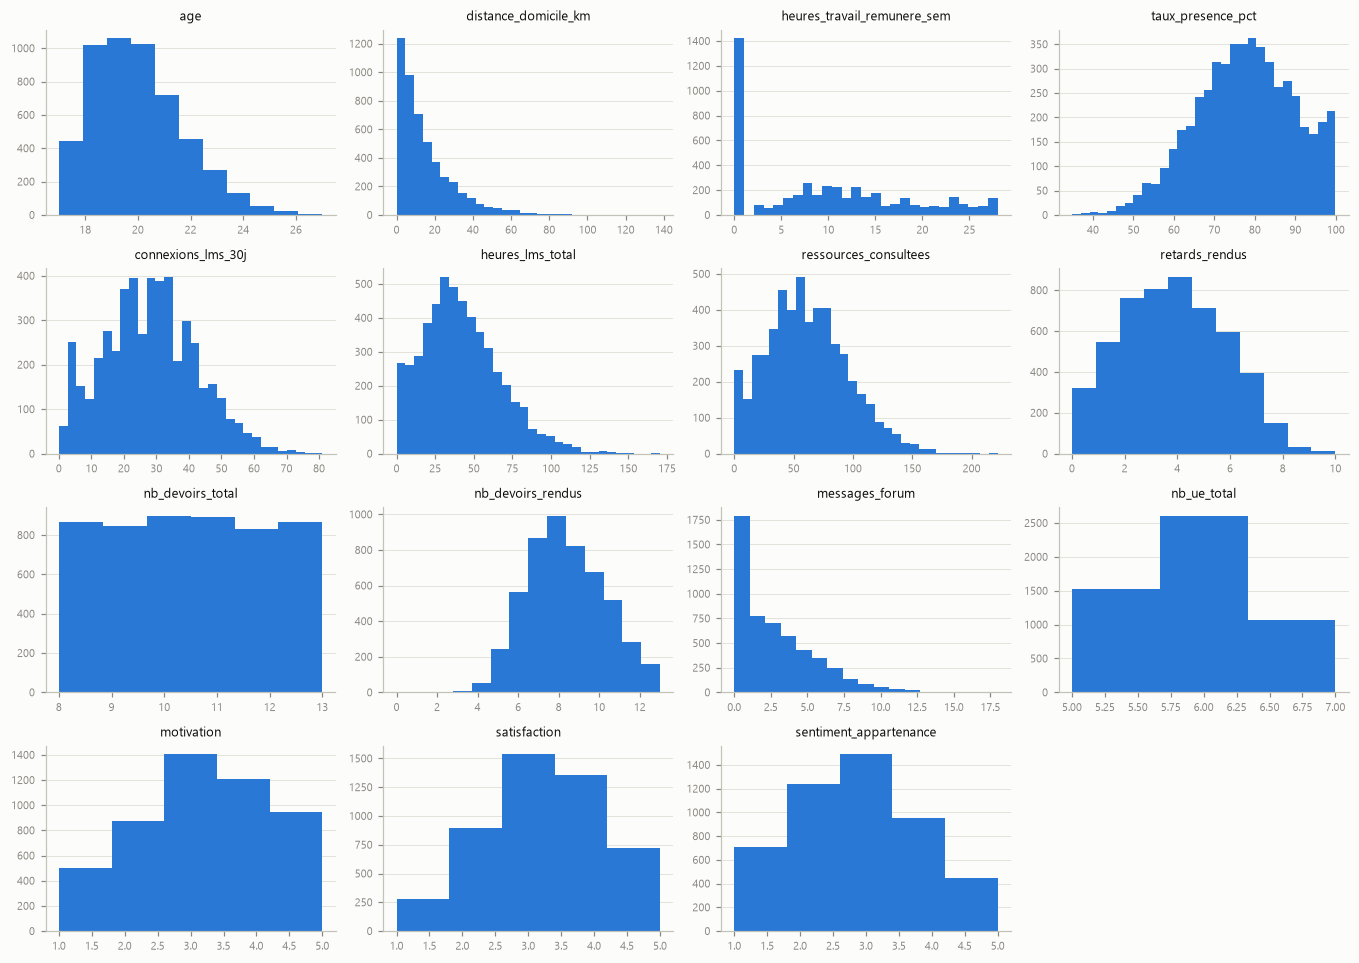

In [37]:
display(eda.numeric_overview(jeu[num_cols]))
eda.show(eda.plot_histograms(jeu[num_cols]))

,colonne,n_modalites,dominante,part_dominante_%,plus_rare,part_rare_%,manquants_%
0,filiere,8,informatique,16.50,lettres,8.15,0.0
1,sexe,4,femme,54.31,non renseigné,0.60,0.0
2,bac_type,3,general,61.48,professionnel,11.56,0.0
3,mention_bac,4,passable,39.10,tres bien,8.87,4.0
4,etablissement_origine,4,lycee_public,69.33,autre,4.17,5.0
5,boursier,2,non,62.02,oui,37.98,0.0
6,groupe_td,8,b,13.23,f,11.15,0.0
7,couleur_carte_etudiante,5,jaune,20.63,vert,19.35,0.0
8,jour_inscription,5,mardi,21.52,lundi,18.96,0.0


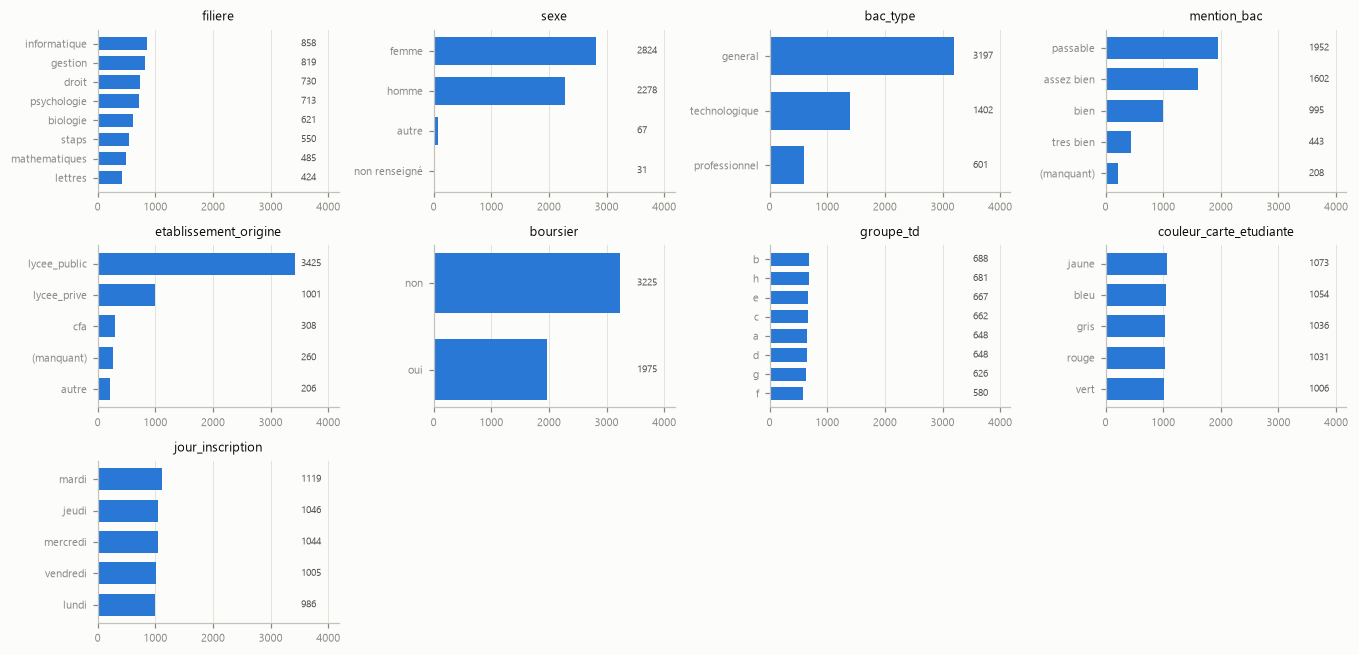

**> Modalités rares (< 1 %)**

,colonne,modalite,n,part_%
0,sexe,non renseigné,31,0.6


In [38]:
display(eda.modality_overview(jeu[cat_cols]))
eda.show(eda.plot_bars({c: eda.modality_counts(jeu[c]) for c in cat_cols}, labels="{:.0f}"))

display(Markdown("**> Modalités rares (< 1 %)**"))
display(eda.rare_modalities(jeu[cat_cols]))

### Interprétation

🔍 **`distance_domicile_km` seule fortement asymétrique** - asymétrie 1,94, moyenne 15,2 > médiane 10,4  
⇒ à lire et imputer par la médiane (§6.4)  

🔍 `messages_forum` (0,95) frôle le seuil 
⇒ variable complet sans NaN - aucune imputation nécessaire

🔍 **Échelles très hétérogènes** - de 1-5 (`motivation`) à 0-222 (`ressources_consultees`)  
⇒ La standardisation des échelles sera à faire dans le `Pipeline` (§9)

🔍 **Aucune variance nulle parmi les explicatives** - écarts-types tous > 0, dominante la plus forte 69 % (`etablissement_origine`)  
⇒ la seule constante (`annee_universitaire`) était déjà hors périmètre (§5) - rien à écarter ici

🔍 **Catégorielles équilibrées** - `filiere` (8 modalités, 8-17 %), `boursier` (38/62), `bac_type`, `mention_bac`  
⇒ rien de dégénéré

🔍 **Leurres `couleur_carte_etudiante`, `groupe_td`, `jour_inscription` quasi uniformes** - ~20 % par modalité  
⇒ cohérent avec des variables décoratives, instruites comme leurres en §6.7

🔍 **Une seule modalité rare (< 1 %)** - `sexe` = `non renseigné` (31 étudiants, 0,6 %), modalité **déclarée**, pas un manquant  
⇒ vocabulaire déclaré à l'encodeur (`handle_unknown="ignore"`, §9) : la colonne ne disparaît pas au découpage train / test

## 6.4 Valeurs manquantes

§5 a compté les valeurs absentes ; reste à qualifier leur **mécanisme** - c'est lui qui commande la stratégie d'imputation, ajustée en §9. Le test de §3.4 : l'absence dépend-elle des **autres variables observées** ? Si oui, MCAR est écarté (distinguer MAR de MNAR reste une hypothèse métier, non testée).

In [39]:
display(eda.missing_overview(jeu[explicatives]))

# Test MCAR : l'indicateur de manquant de chaque colonne trouée est-il lié à une autre
# variable observée, au-delà du bruit ? Si oui, l'absence n'est pas indépendante de tout.
display(eda.missing_mechanism(jeu[explicatives]))

,colonne,n_manquants,part_%
0,heures_travail_remunere_sem,624,12.0
1,satisfaction,416,8.0
2,sentiment_appartenance,364,7.0
3,distance_domicile_km,312,6.0
4,motivation,260,5.0
5,etablissement_origine,260,5.0
6,mention_bac,208,4.0
7,connexions_lms_30j,208,4.0


,colonne,variable_liee,type,mesure,bruit_95,p_permutation,mcar_rejete
0,etablissement_origine,retards_rendus,numérique,0.427,0.262,0.0020,True
1,mention_bac,age,numérique,0.408,0.258,0.0040,True
2,connexions_lms_30j,etablissement_origine,catégorielle,0.053,0.042,0.0080,True
3,motivation,bac_type,catégorielle,0.044,0.036,0.0100,True
4,sentiment_appartenance,satisfaction,numérique,0.146,0.124,0.0319,True
5,satisfaction,date_inscription,catégorielle,0.079,0.077,0.0339,True
6,distance_domicile_km,date_inscription,catégorielle,0.078,0.077,0.0399,True
7,heures_travail_remunere_sem,satisfaction,numérique,0.085,0.094,0.0758,False


,colonne,n_manquants,taux_si_manquant_%,taux_si_present_%,ecart_pt,bruit_95_pt,p_permutation
0,heures_travail_remunere_sem,624,30.93,28.10,2.83,3.73,0.1517
1,satisfaction,416,26.44,28.62,-2.17,4.37,0.3892
2,sentiment_appartenance,364,29.95,28.33,1.62,4.87,0.5210
3,connexions_lms_30j,208,27.40,28.49,-1.08,5.93,0.7465
4,distance_domicile_km,312,27.56,28.50,-0.93,5.54,0.7505
5,etablissement_origine,260,29.23,28.40,0.83,5.65,0.7804
6,mention_bac,208,28.37,28.45,-0.08,6.11,1.0000
7,motivation,260,28.46,28.44,0.02,5.24,1.0000


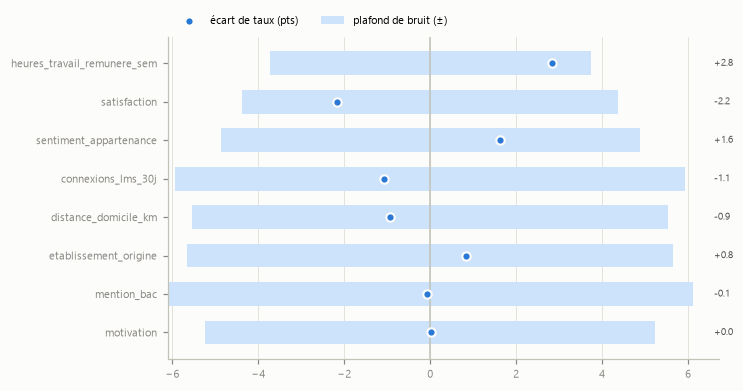

In [40]:
# Complément : l'absence est-elle liée à l'ISSUE ? (oriente l'ajout d'un indicateur x_manquant)
ecarts = eda.missing_vs_target(jeu[explicatives], cible_abandon)
display(ecarts)
eda.show(
    eda.plot_intervals(
        ecarts.set_index("colonne"),
        value="ecart_pt",
        span="bruit_95_pt",
        labels="{:+.1f}",
        legend=("plafond de bruit (±)", "écart de taux (pts)"),
    )
)

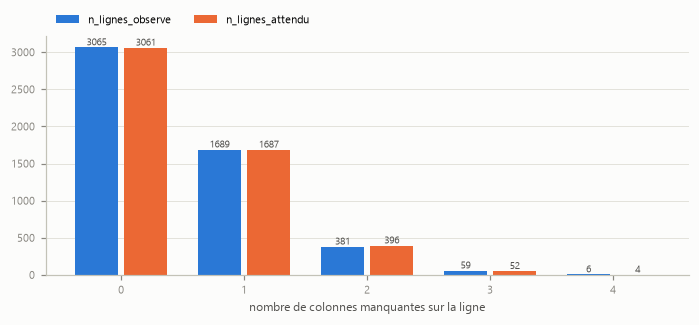

In [41]:
# Les trous se concentrent-ils sur les mêmes dossiers ? Observé face à l'attendu sous indépendance.
concentration = eda.missing_per_row(jeu[explicatives]).set_index("nb_colonnes_manquantes")
eda.show(
    eda.plot_grouped_bars(
        concentration[["n_lignes_observe", "n_lignes_attendu"]],
        labels="{:.0f}",
        xlabel="nombre de colonnes manquantes sur la ligne",
    )
)

### Interprétation

🔍 **⟨constat⟩**  
⇒ ⟨interprétation⟩

## 6.5 Valeurs extrêmes

Je repère les valeurs **rares** par la règle de Tukey (écart interquartile, k = 1,5) sur toutes les numériques, puis je sépare le *rare* du **faux** : le domaine métier déclaré dit ce qui est impossible - une valeur hors IQR mais dans son domaine reste plausible.

,colonne,min,max,borne_basse,borne_haute,n_hors_iqr,part_%
0,satisfaction,1.0,5.0,1.50,5.50,278,5.81
1,distance_domicile_km,0.0,138.0,-20.40,46.00,235,4.81
2,heures_lms_total,0.0,170.5,-26.15,107.85,77,1.48
3,ressources_consultees,0.0,222.0,-32.00,152.00,49,0.94
4,messages_forum,0.0,18.0,-5.00,11.00,34,0.65
5,age,17.0,27.0,13.50,25.50,27,0.52
6,connexions_lms_30j,0.0,81.0,-12.00,68.00,19,0.38
7,taux_presence_pct,34.8,99.9,43.71,112.21,17,0.33
8,retards_rendus,0.0,10.0,-2.50,9.50,13,0.25
9,nb_devoirs_rendus,0.0,13.0,2.50,14.50,7,0.13


**688** lignes portent au moins une valeur hors IQR (sur 5200)

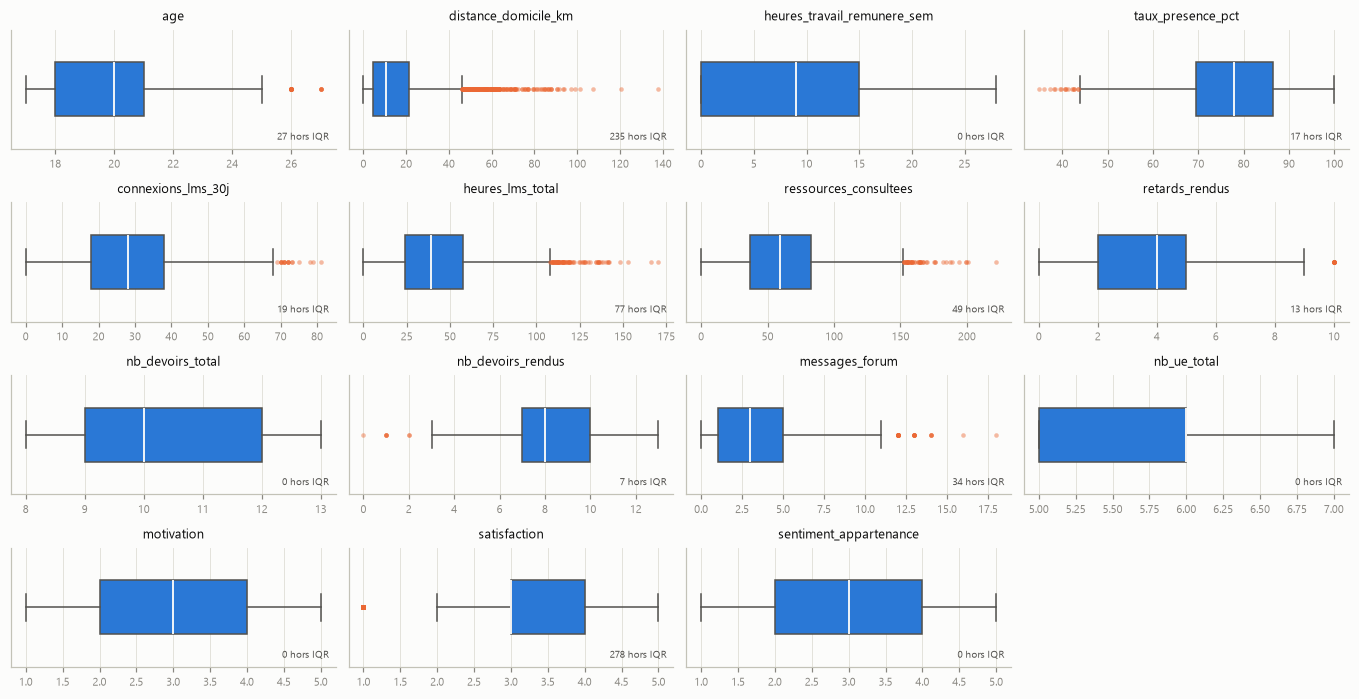

In [42]:
# Règle de Tukey (k = 1,5) : borne_basse = Q1 - 1,5·IQR, borne_haute = Q3 + 1,5·IQR.
extremes = eda.iqr_outliers(jeu[num_cols])
display(extremes)
masque = eda.iqr_mask(jeu[num_cols])
display(
    Markdown(
        f"**{int(masque.any(axis=1).sum())}** lignes portent au moins une valeur hors IQR "
        f"(sur {len(jeu)})"
    )
)
eda.show(
    eda.plot_boxplots(
        jeu[num_cols],
        annotations={r.colonne: f"{r.n_hors_iqr} hors IQR" for r in extremes.itertuples()},
    )
)

,colonne,domaine,min,max,n_hors_domaine,debut_%,fin_%
0,taux_presence_pct,[0 ; 100],34.8,99.9,0,34.8,99.9
1,motivation,[1 ; 5],1.0,5.0,0,0.0,100.0
2,satisfaction,[1 ; 5],1.0,5.0,0,0.0,100.0
3,sentiment_appartenance,[1 ; 5],1.0,5.0,0,0.0,100.0


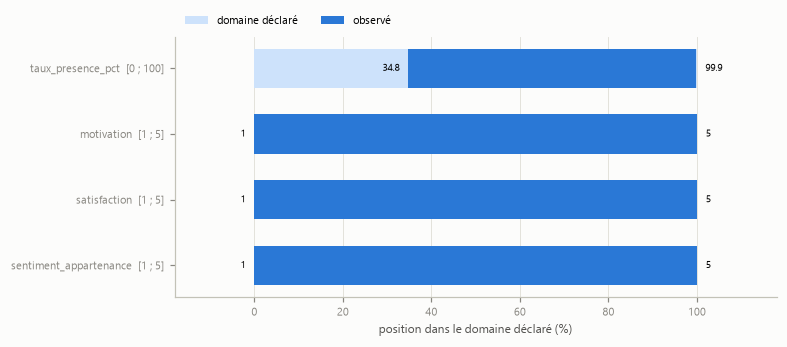

In [43]:
DOMAINES = {  # bornes métier déclarées (à valider) - séparent le FAUX du RARE
    "taux_presence_pct": (0, 100),
    "motivation": (1, 5),
    "satisfaction": (1, 5),
    "sentiment_appartenance": (1, 5),
}
bornees = [c for c in num_cols if c in DOMAINES]
controle = eda.domain_check(jeu[bornees], DOMAINES)
display(controle)
eda.show(eda.plot_domain_occupancy(controle))

### Interprétation

🔍 **⟨constat⟩**  
⇒ ⟨interprétation⟩

## 6.6 Associations

Je mesure d'abord les liens **entre explicatives** - le seul terrain où une redondance justifie d'écarter une colonne - puis, séparément, les liens **avec les cibles**, qui ne servent qu'à décrire et à préparer l'explicabilité de §12. Aucune inclusion ni exclusion ne se décide sur une relation mesurée avec la cible.

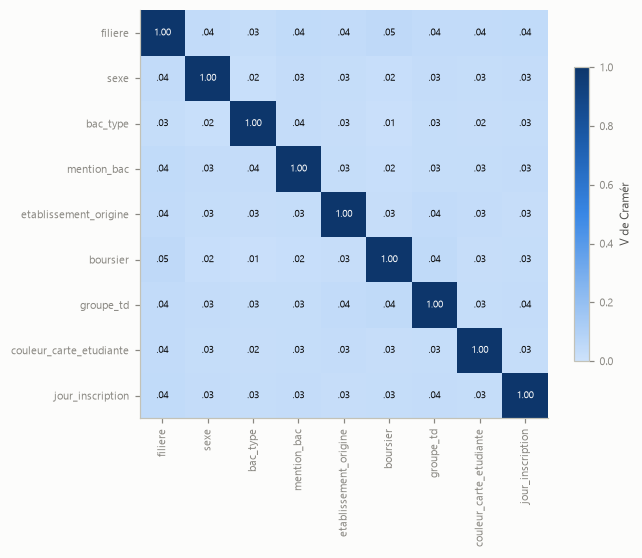

**> Corrélations numériques fortes (|ρ| >= 0,8)**

,variable_1,variable_2,correlation
0,connexions_lms_30j,ressources_consultees,0.920
1,connexions_lms_30j,heures_lms_total,0.869


In [44]:
# Entre explicatives - le seul terrain où une redondance justifie d'écarter une colonne.
eda.show(
    eda.plot_heatmap(
        eda.cramers_v_matrix(jeu[cat_cols]), diverging=False, annotate=True, label="V de Cramér"
    )
)
display(Markdown("**> Corrélations numériques fortes (|r| >= 0,8)**"))
display(eda.correlation_pairs(jeu[num_cols], threshold=0.8))

In [45]:
# Avec les cibles - descriptif seulement, prépare l'explicabilité §12. Aucune sélection ici.
display(Markdown("**> Catégorielles vs `abandon`**"))
display(eda.categorical_association(jeu, cat_cols, cible_abandon))
display(Markdown("**> Catégorielles vs les deux cibles (écart dans l'unité de la cible)**"))
display(
    eda.group_spread_table(
        jeu,
        cat_cols,
        {
            "abandon (pts %)": 100 * eda.as_float(cible_abandon),
            "moyenne_finale (/20)": cible_moyenne,
        },
    )
)

**> Catégorielles vs `abandon`**

,colonne,n_groupes,v_cramer,bruit_95,p_permutation
0,bac_type,3,0.084,0.033,0.0020
1,mention_bac,5,0.048,0.043,0.0259
2,couleur_carte_etudiante,5,0.045,0.041,0.0299
3,jour_inscription,5,0.039,0.043,0.0938
4,filiere,8,0.035,0.052,0.5070
5,groupe_td,8,0.033,0.051,0.5449
6,sexe,4,0.031,0.038,0.1617
7,etablissement_origine,5,0.025,0.042,0.5429
8,boursier,2,0.011,0.029,0.4471


**> Catégorielles vs les deux cibles (écart dans l'unité de la cible)**

,colonne,cible,n_groupes,ecart_observe,bruit_95,p_permutation
0,filiere,abandon (pts %),8,5.469,8.173,0.3932
1,filiere,moyenne_finale (/20),8,0.523,0.992,0.6747
2,sexe,abandon (pts %),4,21.281,19.463,0.0240
3,sexe,moyenne_finale (/20),4,3.476,2.359,0.0020
4,bac_type,abandon (pts %),3,9.283,4.672,0.0020
5,bac_type,moyenne_finale (/20),3,2.311,0.599,0.0020
6,mention_bac,abandon (pts %),5,8.176,8.148,0.0519
7,mention_bac,moyenne_finale (/20),5,1.935,0.984,0.0020
8,etablissement_origine,abandon (pts %),5,6.248,10.057,0.3214
9,etablissement_origine,moyenne_finale (/20),5,0.828,1.158,0.2655


### Interprétation

🔍 **⟨constat⟩**  
⇒ ⟨interprétation⟩

## 6.7 Leurres annoncés

Trois variables annoncées comme du bruit décoratif (§3.6). Je les démontre **nulles** - dérivation déterministe ou lien sous le bruit - au lieu de les croire nulles ; elles restent dans le gold, et §12 (SHAP) conclura.

In [46]:
# `jour_inscription` se recalcule-t-il depuis `date_inscription` ? (dérivation déterministe)
JOURS = {
    0: "lundi",
    1: "mardi",
    2: "mercredi",
    3: "jeudi",
    4: "vendredi",
    5: "samedi",
    6: "dimanche",
}
jour_recalcule = jeu["date_inscription"].dt.weekday.map(JOURS)
comparables = jeu["jour_inscription"].notna() & jour_recalcule.notna()
coincide_jour = (jeu.loc[comparables, "jour_inscription"] == jour_recalcule[comparables]).mean()
display(
    Markdown(
        f"`jour_inscription` = jour de semaine de `date_inscription` sur "
        f"**{100 * coincide_jour:.1f} %** des lignes comparables"
    )
)

`jour_inscription` = jour de semaine de `date_inscription` sur **100.0 %** des lignes comparables

In [47]:
# Les autres leurres : leur lien avec `abandon` sort-il du bruit ?
LEURRES = ["couleur_carte_etudiante", "jour_inscription"]  # 3e leurre : compléter selon §3.6
display(eda.categorical_association(jeu, LEURRES, cible_abandon))

,colonne,n_groupes,v_cramer,bruit_95,p_permutation
0,couleur_carte_etudiante,5,0.045,0.041,0.0299
1,jour_inscription,5,0.039,0.043,0.0938


### Interprétation

🔍 **⟨constat⟩**  
⇒ ⟨interprétation⟩

## Journal de bord [C3]

⟨journal de bord - une entrée par décision **à alternative sérieuse**, au gabarit *Question / Ce que j'ai regardé / Décision / Pourquoi*, avec *Écarté - X, parce que Y* le cas échéant ; à remplir⟩

⟨✅ clôture de section - à remplir⟩

# 7. Préparation des données (nettoyage, manquants, transformations, features) — journal de bord [C3]

# 8. Choix du modèle et démarche scientifique (baseline, modèles, comparaison) — journal de bord [C4]

Contrainte : 
- AUC départage la performance prédictive mais PR-AUC, Rappel, Precision et F1 pertinent à comparer également
- L'explicabilité est un critère du modèle

# 9. Entraînement, validation et ajustement (sélection du modèle final) — journal de bord [C5]

# 10. Implémentation et mise en exploitation (déploiement, exemple d’usage) — journal de bord [C6]

# 11. Architecture cible et contraintes [C7]

# 12. Mesure de performance et impacts (métriques techniques + métier) [C8]

# 13. Amélioration continue (ré-entraînement, suivi, versioning) [C9]

# 14. Conclusion (synthèse et recommandations)


# 15. Annexes (versions, paramètres, dépendances, fonctions utilitaires)